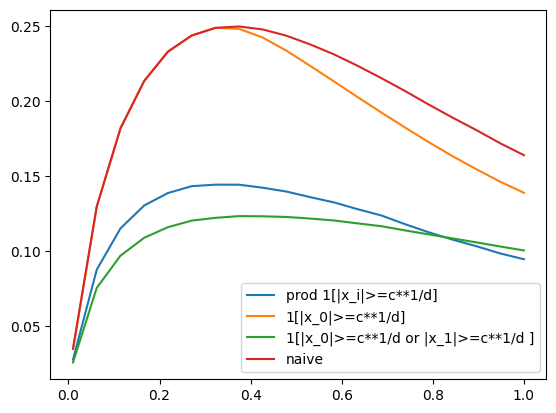

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as s

cdf_gaussian = s.norm.cdf

def experience(seed, n_samples, constant, known_statistic):
  np.random.seed(seed)
  my_samples = np.random.multivariate_normal(np.zeros(dim), np.eye(dim), n_samples)
  statistic_of_interest = np.prod(np.abs(my_samples), axis=-1) <= constant
  eval_known_statistic = known_statistic(my_samples, constant)
  coeff_ols = np.mean((statistic_of_interest-np.mean(statistic_of_interest))*(eval_known_statistic-np.mean(eval_known_statistic)))/np.mean(eval_known_statistic**2)
  estimate = statistic_of_interest-coeff_ols*eval_known_statistic
  return np.mean(estimate), np.var(estimate)

def statistic_1(samples, constant):
  return np.prod(np.abs(samples) >= constant**(1/dim), axis=-1) - \
   (1 - (cdf_gaussian(constant**(1/dim))- \
         cdf_gaussian(-constant**(1/dim))))**(dim)

def statistic_2(samples, constant):
  return np.abs(samples[:,0]) >= constant**(1/dim)- \
   (1 - (cdf_gaussian(constant**(1/dim))- \
         cdf_gaussian(-constant**(1/dim))))**(1)

def statistic_3(samples, constant):
  return np.sum(np.abs(samples[:,:2]) >= constant**(1/dim), axis=-1) - (
      2 * (1 - (cdf_gaussian(constant**(1/dim))- \
                cdf_gaussian(-constant**(1/dim)))) \
      - (((cdf_gaussian(constant**(1/dim))- \
           cdf_gaussian(-constant**(1/dim)))))**2
  )

def statistic_naive(seed, n_samples, constant):
  np.random.seed(seed)
  my_samples = np.random.multivariate_normal(np.zeros(dim), np.eye(dim), n_samples)
  statistic_of_interest = np.prod(np.abs(my_samples), axis=-1) <= constant
  estimate = statistic_of_interest
  return np.mean(estimate), np.var(estimate)

n_samples = 100000
seed = 0
dim = 2
constants = np.linspace(0.01, 1, 20)
variances = np.zeros((4, 20))
for idx, constant in enumerate(constants):
  variances[0, idx] = experience(seed, n_samples, constant, statistic_1)[1]
  variances[1, idx] = experience(seed, n_samples, constant, statistic_2)[1]
  variances[2, idx] = experience(seed, n_samples, constant, statistic_3)[1]
  variances[3, idx] = statistic_naive(seed, n_samples, constant)[1]

plt.plot(constants, variances[0], label="prod 1[|x_i|>=c**1/d]")
plt.plot(constants, variances[1], label="1[|x_0|>=c**1/d]")
plt.plot(constants, variances[2], label="1[|x_0|>=c**1/d or |x_1|>=c**1/d ]")
plt.plot(constants, variances[3], label="naive")
plt.legend()
plt.show()

In [ ]:
variances

array([[0.02745075, 0.08749733, 0.11506685, 0.13040352, 0.13868919,
        0.14328445, 0.14428611, 0.14424826, 0.14223487, 0.13964982,
        0.13592737, 0.13242538, 0.12786712, 0.12367555, 0.11783273,
        0.11242262, 0.10752122, 0.10315922, 0.09834813, 0.09448494],
       [0.03462047, 0.12963958, 0.18191032, 0.21356101, 0.2331104 ,
        0.24386598, 0.24899764, 0.24833894, 0.24249065, 0.23367704,
        0.22353602, 0.21318485, 0.20266413, 0.19239708, 0.18235587,
        0.17254309, 0.16324007, 0.1545612 , 0.14625104, 0.13886341],
       [0.03462047, 0.12963958, 0.18191032, 0.21356101, 0.2331104 ,
        0.24386598, 0.24899764, 0.24991737, 0.24789869, 0.24371468,
        0.2378978 , 0.23126934, 0.22360025, 0.21535562, 0.20674432,
        0.19768259, 0.18899594, 0.18067838, 0.17193005, 0.16397511],
       [0.03462047, 0.12963958, 0.18191032, 0.21356101, 0.2331104 ,
        0.24386598, 0.24899764, 0.24991737, 0.24789869, 0.24371468,
        0.2378978 , 0.23126934, 0.22360025, 0

[0.00426771 0.11651758 0.14125594 0.14668668 0.14110393 0.13224327
 0.12300913 0.11209918 0.10309909 0.09544601]


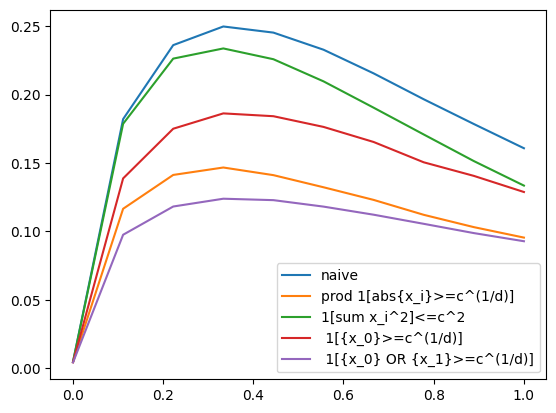

<ipython-input-31-6350e29d41d7>:18: RuntimeWarning: invalid value encountered in scalar divide
  coeff = np.mean((known_statistic - np.mean(known_statistic)) * (


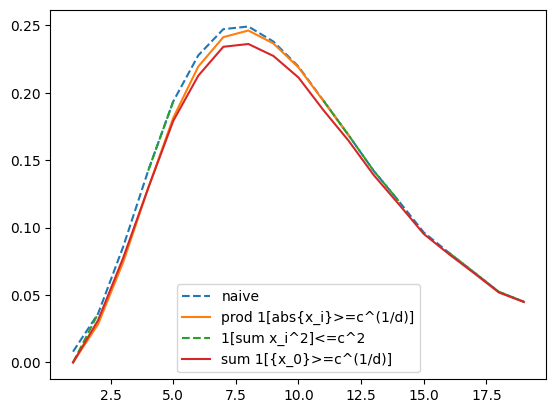

(nan, nan)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as s


def naive_mc(seed, constant, n_samples):
    np.random.seed(seed)
    samples = np.random.multivariate_normal(np.zeros(dim), np.eye(dim), n_samples)
    statistic_of_interest = np.abs(np.prod(samples, axis=-1)) <= constant
    return np.mean(statistic_of_interest), np.var(statistic_of_interest)


def mc_cv(seed, constant, n_samples, f_known_statistic):
    np.random.seed(seed)
    samples = np.random.multivariate_normal(np.zeros(dim), np.eye(dim), n_samples)
    statistic_of_interest = np.abs(np.prod(samples, axis=-1)) <= constant
    known_statistic = f_known_statistic(samples)
    coeff = np.mean((known_statistic - np.mean(known_statistic)) * (
            statistic_of_interest - np.mean(statistic_of_interest))) / np.var(known_statistic)
    return np.mean(statistic_of_interest - coeff * known_statistic), np.var(
        statistic_of_interest - coeff * known_statistic)


def cv_mc(seed, constant, n_samples):
    """
    The statistic is
    """
    known_statistic = lambda samples: np.prod(np.abs(samples) >= constant ** (1 / dim), axis=-1) - (
            1 - (s.norm.cdf(constant ** (1 / dim)) - s.norm.cdf(-constant ** (1 / dim)))) ** (dim)
    return mc_cv(seed, constant, n_samples, known_statistic)


def cv_mc3(seed, constant, n_samples):
    """
    The statistic is
    """
    known_statistic = lambda samples: (np.abs(samples) >= constant ** (1 / dim))[..., 0] - (
            1 - (s.norm.cdf(constant ** (1 / dim)) - s.norm.cdf(-constant ** (1 / dim)))) ** (1)
    return mc_cv(seed, constant, n_samples, known_statistic)


def cv_mc4(seed, constant, n_samples):
    """
    The statistic is
    """
    known_statistic = lambda samples: (np.abs(samples) >= constant ** (1 / dim))[..., :2].sum(axis=-1) - (
                                              2*(1 - (s.norm.cdf(constant ** (1 / dim)) - s.norm.cdf(
                                          -constant ** (1 / dim)))) - ((s.norm.cdf(constant ** (1 / dim)) - s.norm.cdf(
                                          -constant ** (1 / dim))))**2)


    return mc_cv(seed, constant, n_samples, known_statistic)


def cv_mc2(seed, constant, n_samples):
    known_statistic = lambda samples: (np.sum(samples ** 2, axis=-1) <= constant ** 2) - s.chi2.cdf(constant ** 2,
                                                                                                    df=dim)
    return mc_cv(seed, constant, n_samples, known_statistic)


if __name__ == "__main__":
    dim = 2
    csts = np.linspace(0.001, 1, 10)
    res = np.zeros((5, csts.shape[0]))
    for idx, c in enumerate(csts):
        res[0, idx] = naive_mc(0, c, 10000)[1]
        res[1, idx] = cv_mc(0, c, 10000)[1]
        res[2, idx] = cv_mc2(0, c, 10000)[1]
        res[3, idx] = cv_mc3(0, c, 10000)[1]
        res[4, idx] = cv_mc4(0, c, 10000)[1]

    plt.plot(csts, res[0], label="naive")
    plt.plot(csts, res[1], label="prod 1[abs{x_i}>=c^(1/d)]")
    plt.plot(csts, res[2], label="1[sum x_i^2]<=c^2")
    plt.plot(csts, res[3], label=" 1[{x_0}>=c^(1/d)]")
    plt.plot(csts, res[4], label=" 1[{x_0} OR {x_1}>=c^(1/d)]")
    print(res[1])
    plt.legend()
    plt.show()
    var0 = np.zeros(19)
    var1 = np.zeros(19)
    var2 = np.zeros(19)
    var3 = np.zeros(19)
    dims = range(1, 20)
    constant = 0.01
    for idx, d in enumerate(dims):
        dim = d
        var0[idx] = naive_mc(0, constant, 10000)[1]
        var1[idx] = cv_mc(0, constant, 10000)[1]
        var2[idx] = cv_mc2(0, constant, 10000)[1]
        var3[idx] = cv_mc3(0, constant, 10000)[1]

    plt.plot(dims, var0, label="naive", linestyle="--")
    plt.plot(dims, var1, label="prod 1[abs{x_i}>=c^(1/d)]")
    plt.plot(dims, var2, label="1[sum x_i^2]<=c^2", linestyle="--")
    plt.plot(dims, var3, label="sum 1[{x_0}>=c^(1/d)]")
    plt.legend()
    plt.show()

    print(cv_mc2(0, 0.1, 10000))
    """
    Q3. No., Cov(T(X), T(-X)) = 1.
    """